# **Data Representation**

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [6]:
!ls /content/drive/MyDrive/

 1485.pdf
 17344441195391379399712372391215.jpg
 22501A05G2_AntiraggingAffidavitForm.pdf
 22501a05g2_AntiRagging.pdf
'22501A05G2 Blockchain 101 Infosys springboard.pdf'
'22501A05G2 Shaik Irfan Haris.pdf'
'75 (1).png'
'AI Research Papers: Inventory Management.gdoc'
'Air India Web Booking eTicket (V93ZGZ) - IRFAN HARIS.pdf'
"As there are only 4 openings, make sure i'll be i....gdoc"
"A Strategic Guide to Pursuing a Master's in Computer Science in Germany for the 2026 Intake: An In-Depth Analysis for Indian Applicants.gdoc"
'ATTENDANCE (1).docx'
 ATTENDANCE.docx
'AWS Cloud Certifications'
 BCT_G2.docx
'Brain, Beliefs, and Human Potential (1).gdoc'
'Brain, Beliefs, and Human Potential (2).gdoc'
'Brain, Beliefs, and Human Potential (3).gdoc'
'Brain, Beliefs, and Human Potential.gdoc'
'Business letter.gdoc'
'Cert6328431_AgentforceSpecialist_20250703 (1).pdf'
 Cert6328431_AgentforceSpecialist_20250703.pdf
"Certify'em - Personal Copy of Black Saree Template.gslides"
"Certify'em - Personal Copy

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout, Flatten

In [ ]:
tracks = pd.read_csv('/content/predictive_maintenance.csv')

In [ ]:
tracks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Target                   10000 non-null  int64  
 9   Failure Type             10000 non-null  object 
dtypes: float64(3), int64(4), object(3)
memory usage: 781.4+ KB


In [ ]:
tracks.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000


In [ ]:
tracks.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


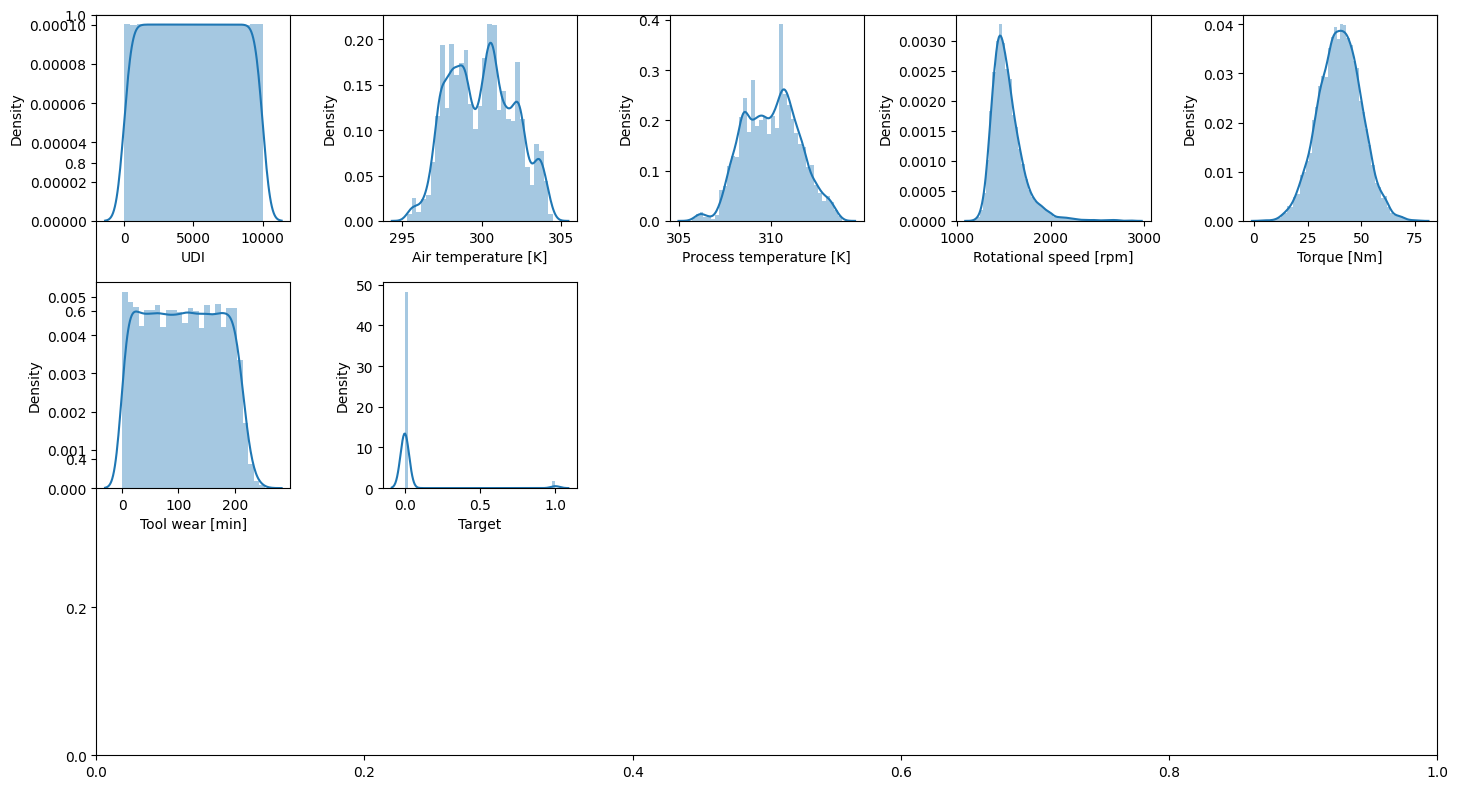

In [ ]:
plt.subplots(figsize=(15, 8))
num_cols = tracks.select_dtypes(include=['float64', 'int64']).columns

num_rows = 3
num_cols_subplot = 5

for i, col in enumerate(num_cols):
    plt.subplot(num_rows, num_cols_subplot, i + 1)
    sb.distplot(tracks[col])
    plt.tight_layout()

plt.show()


In [ ]:
tracks.shape

(10000, 10)

**Data Preprocessing**

In [ ]:
tracks.isnull().sum()
tracks.dropna(inplace=True)

In [ ]:
columns_to_drop = [col for col in ["UDI", "Product ID", "Failure Type"] if col in tracks.columns]
if columns_to_drop:
    tracks.drop(columns_to_drop, axis=1, inplace=True)
else:
    print("All specified columns already dropped.")

In [ ]:
tracks['Target'] = tracks['Target'].astype(int)

In [ ]:
from imblearn.over_sampling import SMOTE
X_encoded = pd.get_dummies(tracks.drop('Target', axis=1), columns=['Type'], drop_first=True)
y = tracks['Target']
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_encoded, y)

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_res)

**Convert Data to Time Series Format (for LSTM)**




In [ ]:
def create_sequences_for_classification(features, targets, sequence_length):
    X, y = [], []
    for i in range(len(features) - sequence_length):
        X.append(features[i:(i + sequence_length)])
        y.append(targets[i + sequence_length])
    return np.array(X), np.array(y)

SEQUENCE_LENGTH = 10
X_ts, y_ts = create_sequences_for_classification(X_scaled, y_res, SEQUENCE_LENGTH)
print(f"Shape of X_ts (sequences): {X_ts.shape}")
print(f"Shape of y_ts (targets): {y_ts.shape}")

Shape of X_ts (sequences): (19312, 10, 7)
Shape of y_ts (targets): (19312,)


### Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X_ts, y_ts, test_size=0.2, random_state=42, stratify=y_ts
)
print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")
print("\nClass distribution in y_train:")
print(pd.Series(y_train).value_counts(normalize=True))
print("\nClass distribution in y_test:")
print(pd.Series(y_test).value_counts(normalize=True))

Shape of X_train: (15449, 10, 7)
Shape of X_test: (3863, 10, 7)
Shape of y_train: (15449,)
Shape of y_test: (3863,)

Class distribution in y_train:
1    0.500227
0    0.499773
Name: proportion, dtype: float64

Class distribution in y_test:
1    0.500388
0    0.499612
Name: proportion, dtype: float64


# Task
Define a CNN+LSTM model architecture, compile it for binary classification, train it using the `X_train`, `y_train` datasets, and evaluate its performance on `X_test`, `y_test` for predictive maintenance, finally summarizing the process and discussing the results.

## Define CNN + LSTM Model Architecture

### Subtask:
Define a CNN-LSTM model architecture using Keras Sequential API for binary classification.


**Reasoning**:
I will define the CNN-LSTM model architecture using Keras Sequential API as per the instructions, including Conv1D, MaxPooling1D, LSTM, Dropout, and Dense layers, and then print the model summary.



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, LSTM, Dense, Dropout
model = Sequential()
model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(MaxPooling1D(pool_size=2))
model.add(Dropout(0.2))
model.add(LSTM(100, return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(50))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 9, 64)          │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 4, 100)         │        66,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 100)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        30,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 97,211 (379.73 KB)

 Trainable params: 97,211 (379.73 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2, verbose=1)
print("Model training complete.")

Epoch 1/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9317 - loss: 0.1714 - val_accuracy: 0.9799 - val_loss: 0.0828
Epoch 2/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9774 - loss: 0.0883 - val_accuracy: 0.9803 - val_loss: 0.0813
Epoch 3/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9795 - loss: 0.0821 - val_accuracy: 0.9786 - val_loss: 0.0912
Epoch 4/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9806 - loss: 0.0791 - val_accuracy: 0.9803 - val_loss: 0.0787
Epoch 5/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9805 - loss: 0.0792 - val_accuracy: 0.9773 - val_loss: 0.0872
Epoch 6/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.9813 - loss: 0.0766 - val_accuracy: 0.9803 - val_loss: 0.0794
Epoch 7/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9813 - loss: 0.0764 - val_accuracy: 0.9803 - val_loss: 0.0788
Epoch 8/50
387/387 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9812 - loss: 0.0763 - val_accu

## Feature Correlation Matrix


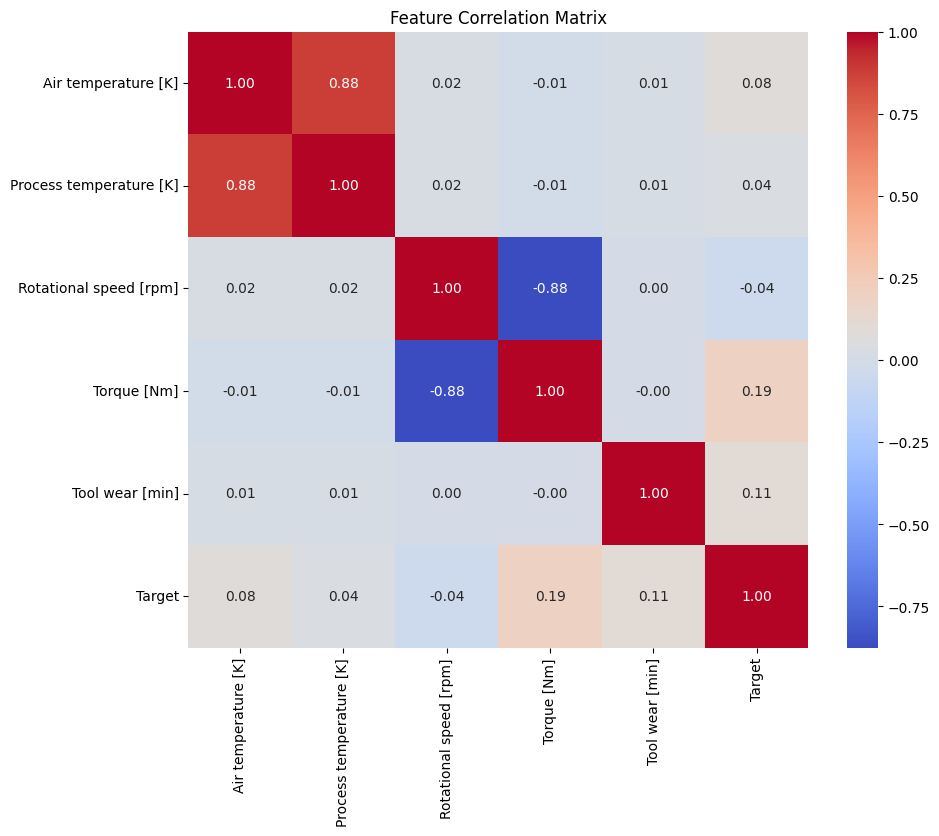

In [ ]:
plt.figure(figsize=(10, 8))
sb.heatmap(tracks.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

**Evaluation Of Model**

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = (model.predict(X_test) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_pred))


121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
[[1930    0]
 [  64 1869]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1930
           1       1.00      0.97      0.98      1933

    accuracy                           0.98      3863
   macro avg       0.98      0.98      0.98      3863
weighted avg       0.98      0.98      0.98      3863

AUC: 0.983445421624418


## Confusion Matrix for CNN-LSTM Model


121/121 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


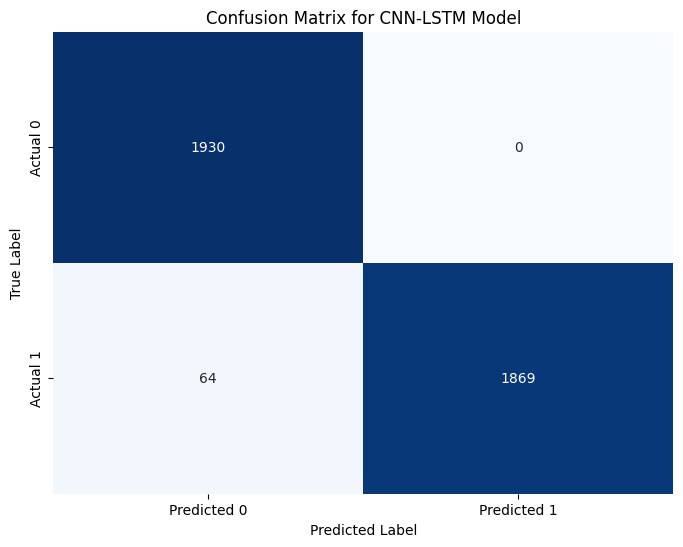

Classification Report:
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      1930
           1       1.00      0.97      0.98      1933

    accuracy                           0.98      3863
   macro avg       0.98      0.98      0.98      3863
weighted avg       0.98      0.98      0.98      3863



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for CNN-LSTM Model')
plt.show()
print("Classification Report:")
print(classification_report(y_test, y_pred))

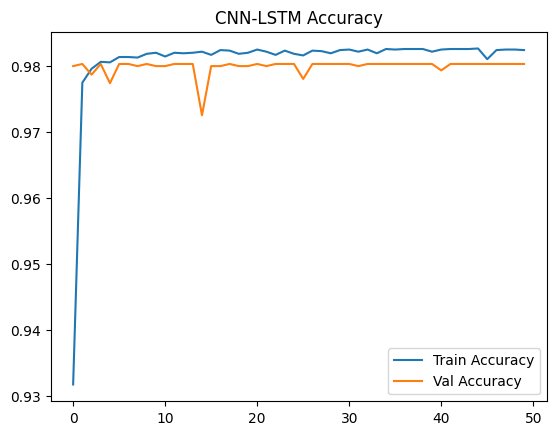

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("CNN-LSTM Accuracy")
plt.show()
